# IAMC Fair Shares Allocation Analysis

**Allocate carbon budgets or emission pathways to IAMC model regions using equity principles.**

This notebook works with IAMC-format data (e.g., MESSAGEix) to calculate
regional fair shares. **Start with principles, not parameters.**

**Before configuring, read:**

- [From Principle to Code](https://setupelz.github.io/fair-shares/science/principle-to-code/) - Principles-first workflow
- [Climate Equity Concepts](https://setupelz.github.io/fair-shares/science/climate-equity-concepts/) - Foundational concepts

**Pre-configured examples:**

- `402_example_iamc_budget_allocations.py` - Budget templates
- `403_example_iamc_pathway_allocations.py` - Pathway templates

**Workflow:**
1. **Load IAMC Data** - From Excel/CSV/pyam
2. **Choose Type** - Budget or pathway allocations?
3. **Define Approach** - Operationalize equity principles
4. **Run & Explore** - Calculate and visualize

In [65]:
# Imports (run this first)
import matplotlib.pyplot as plt
import pandas as pd
from pyprojroot import here

# Import fair-shares library components
from fair_shares.library.allocations.budgets.per_capita import (
    equal_per_capita_budget,
    per_capita_adjusted_budget,
    per_capita_adjusted_gini_budget,
)
from fair_shares.library.allocations.pathways import (
    cumulative_per_capita_convergence,
    cumulative_per_capita_convergence_adjusted,
    cumulative_per_capita_convergence_adjusted_gini,
    equal_per_capita,
    per_capita_adjusted,
    per_capita_adjusted_gini,
)
from fair_shares.library.utils import ensure_string_year_columns
from fair_shares.library.utils.data.iamc import load_iamc_data

# Set matplotlib style
plt.style.use("default")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

project_root = here()

---
## Workflow Overview

This notebook guides you through IAMC regional allocations:

1. **Step 1**: Load your IAMC-format data file
2. **Step 2**: Choose allocation type (budget or pathway)
3. **Step 3**: Define your allocation approach and parameters
4. **Step 4**: Run the allocation
5. **Step 5-7**: Visualize, export, and prepare model inputs

[Learn more about allocation approaches](https://setupelz.github.io/fair-shares/science/allocations/)

---
## Step 1: Load IAMC Data

Load scenario data in IAMC format (Excel, CSV, or pyam database).

**Required variables:**
- Population (for per capita calculations)
- GDP (for capability-based adjustments, optional)
- Emissions (the target being allocated, e.g., `Emissions|CO2`)

In [72]:
# CONFIGURE YOUR DATA SOURCE HERE

# Path to your IAMC-format data file
DATA_FILE = (
    project_root / "data" / "scenarios" / "aim_justmip" / "IAMC20260128_SSP2_reference.xlsx"
)

# IAMC variable names in your file
POPULATION_VARIABLE = "Population"
GDP_VARIABLE = "GDP|PPP"
EMISSIONS_VARIABLE = "Emissions|Covered"  # The emissions being allocated => Shiya: we don't have "Emissions|Covered" in our data, use "Emissions|CO2"
EMISSIONS_VARIABLE = "Emissions|CO2"

# Time range configuration
EARLIEST_DATA_YEAR = 2015  # Must be <= allocation_year in Step 3
MODEL_HORIZON_YEAR = 2100  # Last year in your optimisation framework

# Load the data file to get region list
df = pd.read_excel(DATA_FILE)
df = ensure_string_year_columns(df)
regions = [r for r in df["region"].unique() if r != "World"]

print(f"Data file: {DATA_FILE}")
print(f"Regions found: {len(regions)}")
print(f"Regions: {', '.join(sorted(regions))}")

Data file: /Users/shiya/Desktop/Model/ES_Setu/fair-shares/data/scenarios/aim_justmip/IAMC20260128_SSP2_reference.xlsx
Regions found: 17
Regions: BRA, CAN, CHN, CIS, IND, JPN, TUR, USA, XAF, XE25, XER, XLM, XME, XNF, XOC, XSA, XSE


In [73]:
# Load IAMC data with required variables
data = load_iamc_data(
    data_file=DATA_FILE,
    population_variable=POPULATION_VARIABLE,
    gdp_variable=GDP_VARIABLE,
    emissions_variable=EMISSIONS_VARIABLE,
    regions=regions,
    allocation_start_year=EARLIEST_DATA_YEAR,
    budget_end_year=MODEL_HORIZON_YEAR,
    expand_to_annual=True,
)

print("\nYes Data loaded successfully!")
print(f"Variables: {data['metadata']['variables_loaded']}")
print(f"Time range: {data['metadata']['year_range']}")

# Rename index for allocation functions (expects "iso3c")
population_ts = data["population"].rename_axis(index={"region": "iso3c"})
gdp_ts = data["gdp"].rename_axis(index={"region": "iso3c"})
if "emissions" in data:
    emissions_ts = data["emissions"].rename_axis(index={"region": "iso3c"})
else:
    emissions_ts = None

print("\nReady to proceed to Step 2.")

[INFO] 14:41:37 - pyam.core: Reading file /Users/shiya/Desktop/Model/ES_Setu/fair-shares/data/scenarios/aim_justmip/IAMC20260128_SSP2_reference.xlsx



Yes Data loaded successfully!
Variables: ['Population', 'Emissions|CO2', 'GDP|PPP']
Time range: (2015, 2100)

Ready to proceed to Step 2.


---
## Step 2: Choose Allocation Type

Select whether you want **budget** or **pathway** allocations:

**Budget allocations** (single-year cumulative):
- Distribute a total carbon budget from allocation year onwards
- Result: Regional shares of cumulative budget (0-1, sums to 100%)
- Use for: Setting cumulative constraints in models

**Pathway allocations** (time-series):
- Distribute annual emission pathways over time
- Result: Annual emission allowances by region and year
- Use for: Year-by-year model constraints, visualizing trajectories

[Budget vs pathway guide](https://setupelz.github.io/fair-shares/science/allocations/)

In [81]:
# Choose allocation type
allocation_type = "budget"  # EDIT THIS: "budget" or "pathway"
allocation_type = "pathway"  # EDIT THIS: "budget" or "pathway"

print(f"Allocation type: {allocation_type}")
print("\nReady to proceed to Step 3.")

Allocation type: pathway

Ready to proceed to Step 3.


---
## Step 3: Define Allocation Approach

Operationalize your equity principles.

Ask yourself:

1. Which principles? Equal per capita? Historical responsibility? Capability?
2. Relative weights? If combining principles, what balance?
3. Subsistence protection? Exclude basic-needs emissions?

See [From Principle to Code](https://setupelz.github.io/fair-shares/science/principle-to-code/)

**Available approaches:**

- Budget: `equal-per-capita-budget`, `per-capita-adjusted-budget`, `*-gini-budget`
- Pathway: `equal-per-capita`, `per-capita-adjusted`, `cumulative-per-capita-convergence`, `*-gini-adjusted`

See [Allocation Approaches](https://setupelz.github.io/fair-shares/science/allocations/) for parameters.

In [89]:
# CONFIGURE YOUR ALLOCATION APPROACH HERE

# Choose approach name
approach = "equal-per-capita-budget"  # EDIT THIS
approach = "per-capita-adjusted"  # for historical responsibility pathway approach

# Configure approach parameters
# - Equal per capita: budget approach, “equal-per-capita-budget”. No parameters needed
# - Historical responsibility: pathway approach, "per-capita-adjusted". Set responsibility_weight, historical_responsibility_year
# - Capability: Set capability_weight
# - Subsistence protection: Set income_floor, max_gini_adjustment

approach_params = {
    # Allocation year (required) - when the allocation begins
    "allocation_year": 2015,
    # Example parameters (uncomment and edit as needed):
    "responsibility_weight": 0.5,
    # "capability_weight": 0.5,
    "historical_responsibility_year": 1990,
    # "income_floor": 7500,
    # "max_gini_adjustment": 0.8,
    # "convergence_year": 2050,
}

# Validate required data for approach parameters
if "responsibility_weight" in approach_params and emissions_ts is None:
    raise ValueError(
        "Approach requires historical emissions data. "
        "Set EMISSIONS_VARIABLE to load emissions or remove 'responsibility_weight' parameter."
    )

if "capability_weight" in approach_params and gdp_ts is None:
    raise ValueError(
        "Approach requires GDP data. "
        "Ensure GDP_VARIABLE is set or remove 'capability_weight' parameter."
    )

if "gini" in approach:
    gini_data = data.get("gini")
    if gini_data is None:
        raise ValueError(
            "Approach requires Gini coefficient data but none was loaded. "
            "Ensure your data file contains Gini data or use a non-gini approach."
        )

# Validate convergence approaches require emissions data
if allocation_type == "pathway" and "convergence" in approach:
    if emissions_ts is None:
        raise ValueError(
            "Convergence approaches require historical emissions data. "
            "Set EMISSIONS_VARIABLE to load emissions data."
        )

# Extract allocation_year for use in allocation functions
allocation_year = approach_params["allocation_year"]

print(f"Approach: {approach}")
print(f"Allocation year: {allocation_year}")
print(f"Parameters: {approach_params}")
print("\nReady to run allocations!")

Approach: per-capita-adjusted
Allocation year: 2015
Parameters: {'allocation_year': 2015, 'responsibility_weight': 0.5, 'historical_responsibility_year': 1990}

Ready to run allocations!


---
## Step 4: Run Allocation

**Automated** - Just run the cell below.

In [90]:
print("=" * 70)
print("RUNNING ALLOCATION")
print("=" * 70)
print(f"\nApproach: {approach}")
print(f"Type: {allocation_type}")
print(f"Allocation year: {allocation_year}")
print("")

population_ts.to_excel(project_root / "population_ts.xlsx")
# print(population_ts.data.index.is_unique)
# print(population_ts.data.index.duplicated().sum())



RUNNING ALLOCATION

Approach: per-capita-adjusted
Type: pathway
Allocation year: 2015



In [95]:

# Select the appropriate allocation function
print(f"print allocation year: {allocation_year}")
if allocation_type == "budget":
    if approach == "equal-per-capita-budget":
        allocation_func = equal_per_capita_budget
    elif approach == "per-capita-adjusted-budget":
        allocation_func = per_capita_adjusted_budget
    elif approach == "per-capita-adjusted-gini-budget":
        allocation_func = per_capita_adjusted_gini_budget
    else:
        raise ValueError(f"Unknown budget approach: {approach}, approach: {approach}")
    
    print(f"Running budget allocation of type: {allocation_type}")
    # Build kwargs based on approach
    kwargs = {
        "population_ts": population_ts,
        "allocation_year": allocation_year,
        "emission_category": EMISSIONS_VARIABLE,
        "preserve_allocation_year_shares": False,
        "group_level": "iso3c",
        **approach_params,
    }

    # Add optional parameters for adjusted approaches
    if approach != "equal-per-capita-budget":
        if "capability_weight" in approach_params:
            kwargs["gdp_ts"] = gdp_ts
        if "gini" in approach:
            kwargs["gini_s"] = data.get("gini")
        if "responsibility_weight" in approach_params:
            kwargs["country_actual_emissions_ts"] = emissions_ts

    # Run budget allocation
    result = allocation_func(**kwargs)

    # Extract shares
    shares = result.relative_shares_cumulative_emission[str(allocation_year)]
    shares = shares.droplevel(["unit", "emission-category"])

    print("\nRegional Budget Shares:\n")
    print(f"{'Region':8s} {'Share':>10s}")
    print("-" * 20)
    for region in sorted(shares.index):
        print(f"{region:8s} {shares[region]*100:9.2f}%")

elif allocation_type == "pathway":
    if approach == "equal-per-capita":
        allocation_func = equal_per_capita
    elif approach == "per-capita-adjusted":
        allocation_func = per_capita_adjusted
    elif approach == "per-capita-adjusted-gini":
        allocation_func = per_capita_adjusted_gini
    elif approach == "cumulative-per-capita-convergence":
        allocation_func = cumulative_per_capita_convergence
    elif approach == "cumulative-per-capita-convergence-adjusted":
        allocation_func = cumulative_per_capita_convergence_adjusted
    elif approach == "cumulative-per-capita-convergence-gini-adjusted":
        allocation_func = cumulative_per_capita_convergence_adjusted_gini
    else:
        raise ValueError(f"Unknown pathway approach: {approach}")
    print(f"Running pathway allocation of type: {allocation_type}, approach: {approach}")

    # Build kwargs based on approach
    kwargs = {
        "population_ts": population_ts,
        "first_allocation_year": allocation_year,
        "emission_category": EMISSIONS_VARIABLE,
        "group_level": "iso3c",
        # **approach_params,
        **{k: v for k, v in approach_params.items() if k != "allocation_year"},
    }

    print("kwargs before optional parameters:")
    print(kwargs)

    # Add preserve parameter for non-convergence approaches
    if "convergence" not in approach:
        kwargs["preserve_first_allocation_year_shares"] = False

    # Add optional parameters based on approach
    if approach != "equal-per-capita":
        if "capability_weight" in approach_params:
            kwargs["gdp_ts"] = gdp_ts
        if "gini" in approach:
            kwargs["gini_s"] = data.get("gini")
        if "responsibility_weight" in approach_params:
            kwargs["country_actual_emissions_ts"] = emissions_ts

    # Convergence approaches require world scenario emissions (required parameters, not optional)
    if "convergence" in approach:
        world_emissions_ts = emissions_ts[
            emissions_ts.index.get_level_values("iso3c") == "World"
        ]
        kwargs["world_scenario_emissions_ts"] = world_emissions_ts
        kwargs["country_actual_emissions_ts"] = emissions_ts  # Required for convergence

    # Run pathway allocation
    print("kwargs after optional parameters but before function:")
    print(kwargs)
    print(f"Calling allocation year: {allocation_year}")
    print(allocation_year)

    result = allocation_func(**kwargs)


    # Extract shares for first year
    shares = result.relative_shares_pathway_emissions[str(allocation_year)]
    shares = shares.droplevel(["unit", "emission-category"])

    print(f"\nRegional Pathway Shares (year {allocation_year}):\n")
    print(f"{'Region':8s} {'Share':>10s}")
    print("-" * 20)
    for region in sorted(shares.index):
        print(f"{region:8s} {shares[region]*100:9.2f}%")

print("\n" + "=" * 70)
print("ALLOCATION COMPLETED SUCCESSFULLY!")
print("=" * 70)

print allocation year: 2015
Running pathway allocation of type: pathway, approach: per-capita-adjusted
kwargs before optional parameters:
{'population_ts':                     2015       2016       2017       2018       2019  \
iso3c unit                                                             
BRA   million   204.2981   212.2714   212.2714   212.2714   212.2714   
CAN   million    35.7468    38.0539    38.0539    38.0539    38.0539   
CHN   million  1391.8556  1423.4391  1423.4391  1423.4391  1423.4391   
CIS   million   287.9708   293.3036   293.3036   293.3036   293.3036   
IND   million  1306.1441  1378.7353  1378.7353  1378.7353  1378.7353   
JPN   million   125.7678   124.8973   124.8973   124.8973   124.8973   
TUR   million    77.5792    82.7032    82.7032    82.7032    82.7032   
USA   million   322.1540   332.9740   332.9740   332.9740   332.9740   
XAF   million   996.7445  1137.6001  1137.6001  1137.6001  1137.6001   
XE25  million   476.9173   482.9350   482.9350   482

DataProcessingError: Data structure error in Country Emissions.

WHAT HAPPENED:
  The data has the wrong index structure.
  Expected: ['iso3c', 'unit', 'emission-category'] (country code and unit columns as index)
  Got: ['iso3c', 'unit'] (current structure)

LIKELY CAUSE:
  The CSV was loaded without setting the index columns.

HOW TO FIX:
  After loading your data, set the index:
  >>> df = df.set_index(['iso3c', 'unit', 'emission-category'])

---
## Step 5: Visualize Results

Visualize allocation shares and compare with historical emissions.

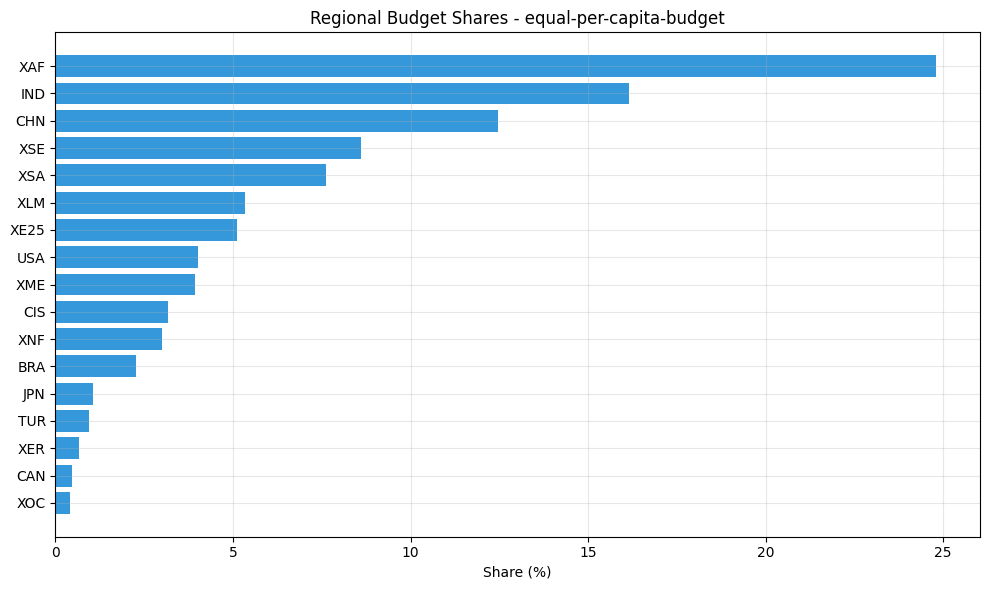

In [ ]:
# Visualization
if allocation_type == "budget":
    # Bar chart for budget allocations (single year)
    fig, ax = plt.subplots(figsize=(10, 6))
    sorted_regions = shares.sort_values(ascending=True).index
    ax.barh(sorted_regions, shares[sorted_regions] * 100, color="#3498db")
    ax.set_xlabel("Share (%)")
    ax.set_title(f"Regional Budget Shares - {approach}")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    # Time-series plot for pathway allocations
    pathway_df = result.relative_shares_pathway_emissions
    year_cols = [col for col in pathway_df.columns if col.isdigit()]
    years = [int(y) for y in year_cols]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot each region
    for region in pathway_df.index.get_level_values("iso3c").unique():
        region_data = pathway_df[pathway_df.index.get_level_values("iso3c") == region]
        ax.plot(
            years,
            region_data[year_cols].values[0] * 100,
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=region,
        )

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Regional Share (%)", fontsize=12)
    ax.set_title(f"Pathway Allocation Shares Over Time - {approach}", fontsize=14)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Step 6: Export Results

Export allocations for use in models or further analysis.

In [ ]:
# Export to CSV
output_file = (
    project_root / "output" / f"iamc_{allocation_type}_allocation_{approach}.csv"
)
output_file.parent.mkdir(parents=True, exist_ok=True)

# Create output dataframe
if allocation_type == "budget":
    output_df = shares.to_frame(name="share")
else:
    # For pathways, include all years
    output_df = result.relative_shares_pathway_emissions.copy()

output_df.to_csv(output_file)
print(f"\nResults exported to: {output_file}")


Results exported to: /Users/shiya/Desktop/Model/ES_Setu/fair-shares/output/iamc_budget_allocation_equal-per-capita-budget.csv


---
## Step 7: Prepare for IAM Model Input (Optional)

Convert allocations to remaining budgets for your IAM model (MESSAGE-ix, GCAM, etc.).

**Understanding timesteps vs periods:**
- IAM models often use timestep labels (e.g., 2030) that represent multi-year periods
- Example: MESSAGEix timestep "2030" represents period 2026-2030
- Your remaining budget should start from the first year of the period, not the timestep label

**Calculation:**
```
Remaining Budget (from 2026) = Allocation (from 2015) - Actual Emissions (2015-2025)
```

**Important:**
- This section only applies to budget allocations, not pathway allocations
- Pathway allocations are already annual and can be used directly
- For pathway allocations, skip this section and use Step 6 exports directly

In [ ]:
# CONFIGURE MODEL SETTINGS
PREPARE_MODEL_INPUT = True  # SET TO True TO ENABLE THIS SECTION

if not PREPARE_MODEL_INPUT:
    print("Model input preparation SKIPPED (set PREPARE_MODEL_INPUT=True to enable)")
elif allocation_type != "budget":
    print(
        "Model input preparation is only for budget allocations. "
        "For pathway allocations, use the exports from Step 6 directly."
    )
else:
    # Model timestep configuration
    FIRST_MODEL_TIMESTEP = 2030  # The timestep label in your model
    FIRST_PERIOD_START = 2026  # First year of the period
    FIRST_PERIOD_END = 2030  # Last year of the period

    print("Model Configuration:")
    print(f"  First timestep: {FIRST_MODEL_TIMESTEP}")
    print(f"  Period: {FIRST_PERIOD_START}-{FIRST_PERIOD_END}")
    print(f"  Allocation starts: {allocation_year}")
    print(f"  Subtract emissions: {allocation_year}-{FIRST_PERIOD_START-1}")

Model Configuration:
  First timestep: 2030
  Period: 2026-2030
  Allocation starts: 2015
  Subtract emissions: 2015-2025


In [ ]:
if PREPARE_MODEL_INPUT and allocation_type == "budget":
    from fair_shares.library.utils.data.iamc import calculate_cumulative_emissions

    # Check that emissions data was loaded
    if emissions_ts is None:
        raise ValueError(
            "Emissions data required for remaining budget calculation. "
            "Ensure EMISSIONS_VARIABLE is set to load emissions data."
        )

    # Load actual emissions from the original file
    emissions_df = df[df["variable"] == EMISSIONS_VARIABLE].set_index("region")

    # Calculate global cumulative budget from scenario
    print("\n" + "=" * 70)
    print("CALCULATING GLOBAL CUMULATIVE BUDGET FROM SCENARIO")
    print("=" * 70)
    print(
        f"\nSumming all regions' emissions from {allocation_year} to {MODEL_HORIZON_YEAR}..."
    )

    regional_cumulative = calculate_cumulative_emissions(
        emissions_ts=emissions_df.reset_index().set_index("region"),
        start_year=allocation_year,
        end_year=MODEL_HORIZON_YEAR,
        unit_conversion=1.0 / 1000,  # Mt to Gt
    )

    total_budget_gt = regional_cumulative.sum()
    print(f"Total scenario emissions: {total_budget_gt:.2f} Gt\n")

    # Calculate absolute fair share allocations
    starting_alloc = shares * total_budget_gt

    print("=" * 70)
    print(f"STEP 1: Starting Allocation (fair share from {allocation_year})")
    print("=" * 70)
    print(f"\nTotal global budget: {total_budget_gt:.2f} Gt\n")
    print(f"{'Region':8s} {'Share':>10s} {'Budget (Gt)':>12s}")
    print("-" * 32)
    for region in sorted(shares.index):
        print(f"{region:8s} {shares[region]*100:9.2f}% {starting_alloc[region]:11.2f}")

    # Calculate actual emissions from allocation_year to (FIRST_PERIOD_START - 1)
    print("\n" + "=" * 70)
    print(f"STEP 2: Actual Emissions ({allocation_year}-{FIRST_PERIOD_START-1})")
    print("=" * 70)
    print("\nThese emissions have ALREADY OCCURRED. They must be subtracted.\n")

    actual_emissions = calculate_cumulative_emissions(
        emissions_ts=emissions_df.reset_index().set_index("region"),
        start_year=allocation_year,
        end_year=FIRST_PERIOD_START - 1,
        unit_conversion=1.0 / 1000,  # Mt to Gt
    )

    print(f"{'Region':8s} {'Emissions (Gt)':>15s}")
    print("-" * 25)
    for region in sorted(shares.index):
        print(f"{region:8s} {actual_emissions[region]:14.2f}")

    # Calculate remaining budget
    print("\n" + "=" * 70)
    print(f"STEP 3: Remaining Budget (from {FIRST_PERIOD_START} onwards)")
    print("=" * 70)
    print("\nRemaining = Starting Allocation - Actual Emissions\n")

    remaining = starting_alloc - actual_emissions

    print(f"{'Region':8s} {'Starting':>12s} {'Emitted':>12s} {'Remaining':>12s}")
    print("-" * 48)
    for region in sorted(shares.index):
        start = starting_alloc[region]
        emitted = actual_emissions[region]
        remain = remaining[region]
        print(f"{region:8s} {start:12.2f} {emitted:12.2f} {remain:12.2f}")

    # Check for negative remaining budgets
    exhausted = remaining[remaining < 0]
    if len(exhausted) > 0:
        print("\nWARNING: Some regions have EXHAUSTED their fair share allocation!")
        print("   Their remaining budget is NEGATIVE:\n")
        for region in exhausted.index:
            print(f"   {region}: {remaining[region]:.2f} Gt (overshoot)")

    # Export remaining budget
    output_file_remaining = (
        project_root
        / "output"
        / f"iamc_remaining_budget_from_{FIRST_PERIOD_START}_{approach}.csv"
    )
    remaining_df = pd.DataFrame(
        {"region": remaining.index, "remaining_budget_gtco2e": remaining.values}
    )
    remaining_df.to_csv(output_file_remaining, index=False)

    print("\n" + "=" * 70)
    print("REMAINING BUDGET CALCULATION COMPLETE")
    print("=" * 70)
    print(f"\nResults exported to: {output_file_remaining}")


CALCULATING GLOBAL CUMULATIVE BUDGET FROM SCENARIO

Summing all regions' emissions from 2015 to 2100...
Total scenario emissions: 1892.68 Gt

STEP 1: Starting Allocation (fair share from 2015)

Total global budget: 1892.68 Gt

Region        Share  Budget (Gt)
--------------------------------
BRA           2.26%       42.84
CAN           0.45%        8.61
CHN          12.47%      236.05
CIS           3.17%       60.04
IND          16.14%      305.47
JPN           1.06%       20.03
TUR           0.96%       18.12
USA           4.02%       76.10
XAF          24.80%      469.35
XE25          5.10%       96.60
XER           0.66%       12.40
XLM           5.32%      100.77
XME           3.94%       74.63
XNF           3.01%       56.89
XOC           0.40%        7.64
XSA           7.63%      144.34
XSE           8.60%      162.80

STEP 2: Actual Emissions (2015-2025)

These emissions have ALREADY OCCURRED. They must be subtracted.

Region    Emissions (Gt)
-------------------------
BRA    